# 📸 Captura de Fotos — Fase 4 Reconocimiento Facial

**Instrucciones para tu compañero:**
1. Ejecuta las celdas en orden
2. Escribe tu nombre cuando se te pida
3. Presiona **ESPACIO** para capturar cada foto
4. Mueve levemente la cabeza entre fotos (izquierda, derecha, arriba, abajo)
5. Al terminar comprime la carpeta `dataset_facial_fase4/` y mándala

> ⚠️ **No cierres el notebook hasta que veas el mensaje de confirmación final**

In [5]:
# Cell 1 — Instalar dependencias
!pip install opencv-python -q
print('✅ Listo')

✅ Listo


In [6]:
# Cell 2 — Configuración
import cv2, os
from pathlib import Path

DATASET_DIR = 'dataset_facial_fase4'
N_FOTOS     = 50

# ── Escribe tu nombre aquí (sin espacios, usa guion bajo) ────────────────────
# Ejemplos: 'pedro_garcia', 'ana_lopez', 'carlos'
NOMBRE = input('👤 Escribe tu nombre (sin espacios): ').strip().lower().replace(' ', '_')

if not NOMBRE:
    print('⚠️  No escribiste un nombre — vuelve a ejecutar esta celda')
else:
    carpeta = Path(f'{DATASET_DIR}/{NOMBRE}')
    carpeta.mkdir(parents=True, exist_ok=True)
    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    print(f'✅ Nombre registrado : {NOMBRE}')
    print(f'   Carpeta de destino: {carpeta}/')
    print(f'   Fotos a capturar  : {N_FOTOS}')

✅ Nombre registrado : memo
   Carpeta de destino: dataset_facial_fase4\memo/
   Fotos a capturar  : 50


In [7]:
# Cell 3 — Captura de fotos
# Presiona ESPACIO para capturar — Q para salir

ya_hay     = len(list(carpeta.glob('*.jpg')))
faltantes  = max(0, N_FOTOS - ya_hay)

if faltantes == 0:
    print(f'✅ Ya tienes {ya_hay} fotos guardadas — ejecuta la Cell 4 para verificarlas')
else:
    print(f'📸 Capturando {faltantes} fotos...')
    print('   🟢 Verde  = cara detectada → presiona ESPACIO para capturar')
    print('   🔴 Sin recuadro = no hay cara detectada → acércate a la cámara')
    print('   Q = salir')

    cap        = cv2.VideoCapture(0)
    contador   = ya_hay
    capturadas = 0

    while capturadas < faltantes:
        ret, frame = cap.read()
        if not ret: break

        gray    = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        rostros = face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(80,80))

        display = frame.copy()

        # Dibujar recuadro alrededor de la cara
        for (x, y, w, h) in rostros:
            cv2.rectangle(display, (x,y), (x+w,y+h), (0,255,0), 2)

        # Barra superior con instrucciones
        estado = '✔ Cara detectada — ESPACIO para capturar' if len(rostros) > 0 \
                 else '✗ No se detecta cara — acércate'
        color_estado = (0,220,0) if len(rostros) > 0 else (0,0,220)

        cv2.rectangle(display, (0,0), (display.shape[1], 50), (30,30,30), -1)
        cv2.putText(display,
            f'{NOMBRE}  |  {capturadas}/{faltantes} fotos  |  {estado}',
            (10, 33), cv2.FONT_HERSHEY_SIMPLEX, 0.65, color_estado, 2)

        # Barra inferior
        cv2.rectangle(display,
            (0, display.shape[0]-35),
            (display.shape[1], display.shape[0]), (30,30,30), -1)
        cv2.putText(display,
            'ESPACIO = capturar foto   |   Q = salir',
            (10, display.shape[0]-10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (180,180,180), 1)

        cv2.imshow('Captura de Fotos — Fase 4', display)
        key = cv2.waitKey(1) & 0xFF

        if key == ord(' '):
            if len(rostros) > 0:
                x, y, w, h = rostros[0]
                rostro = frame[y:y+h, x:x+w]
                ruta   = carpeta / f'{NOMBRE}_{contador:03d}.jpg'
                cv2.imwrite(str(ruta), rostro)
                contador   += 1
                capturadas += 1
                print(f'  📷 Foto {capturadas}/{faltantes} guardada')
            else:
                print('  ⚠️  No hay cara en el frame — acércate e intenta de nuevo')

        elif key == ord('q'):
            print('  ⏹  Saliste antes de terminar')
            break

    cap.release()
    cv2.destroyAllWindows()
    total = len(list(carpeta.glob('*.jpg')))
    print(f'\n✅ Captura finalizada — {total} fotos en total para {NOMBRE}')

📸 Capturando 50 fotos...
   🟢 Verde  = cara detectada → presiona ESPACIO para capturar
   🔴 Sin recuadro = no hay cara detectada → acércate a la cámara
   Q = salir
  📷 Foto 1/50 guardada
  📷 Foto 2/50 guardada
  📷 Foto 3/50 guardada
  📷 Foto 4/50 guardada
  📷 Foto 5/50 guardada
  📷 Foto 6/50 guardada
  📷 Foto 7/50 guardada
  📷 Foto 8/50 guardada
  📷 Foto 9/50 guardada
  📷 Foto 10/50 guardada
  📷 Foto 11/50 guardada
  📷 Foto 12/50 guardada
  📷 Foto 13/50 guardada
  📷 Foto 14/50 guardada
  📷 Foto 15/50 guardada
  📷 Foto 16/50 guardada
  📷 Foto 17/50 guardada
  📷 Foto 18/50 guardada
  📷 Foto 19/50 guardada
  📷 Foto 20/50 guardada
  📷 Foto 21/50 guardada
  📷 Foto 22/50 guardada
  📷 Foto 23/50 guardada
  📷 Foto 24/50 guardada
  📷 Foto 25/50 guardada
  📷 Foto 26/50 guardada
  📷 Foto 27/50 guardada
  📷 Foto 28/50 guardada
  📷 Foto 29/50 guardada
  📷 Foto 30/50 guardada
  📷 Foto 31/50 guardada
  📷 Foto 32/50 guardada
  📷 Foto 33/50 guardada
  📷 Foto 34/50 guardada
  📷 Foto 35/50 guardada
  📷 

Total de fotos encontradas: 50


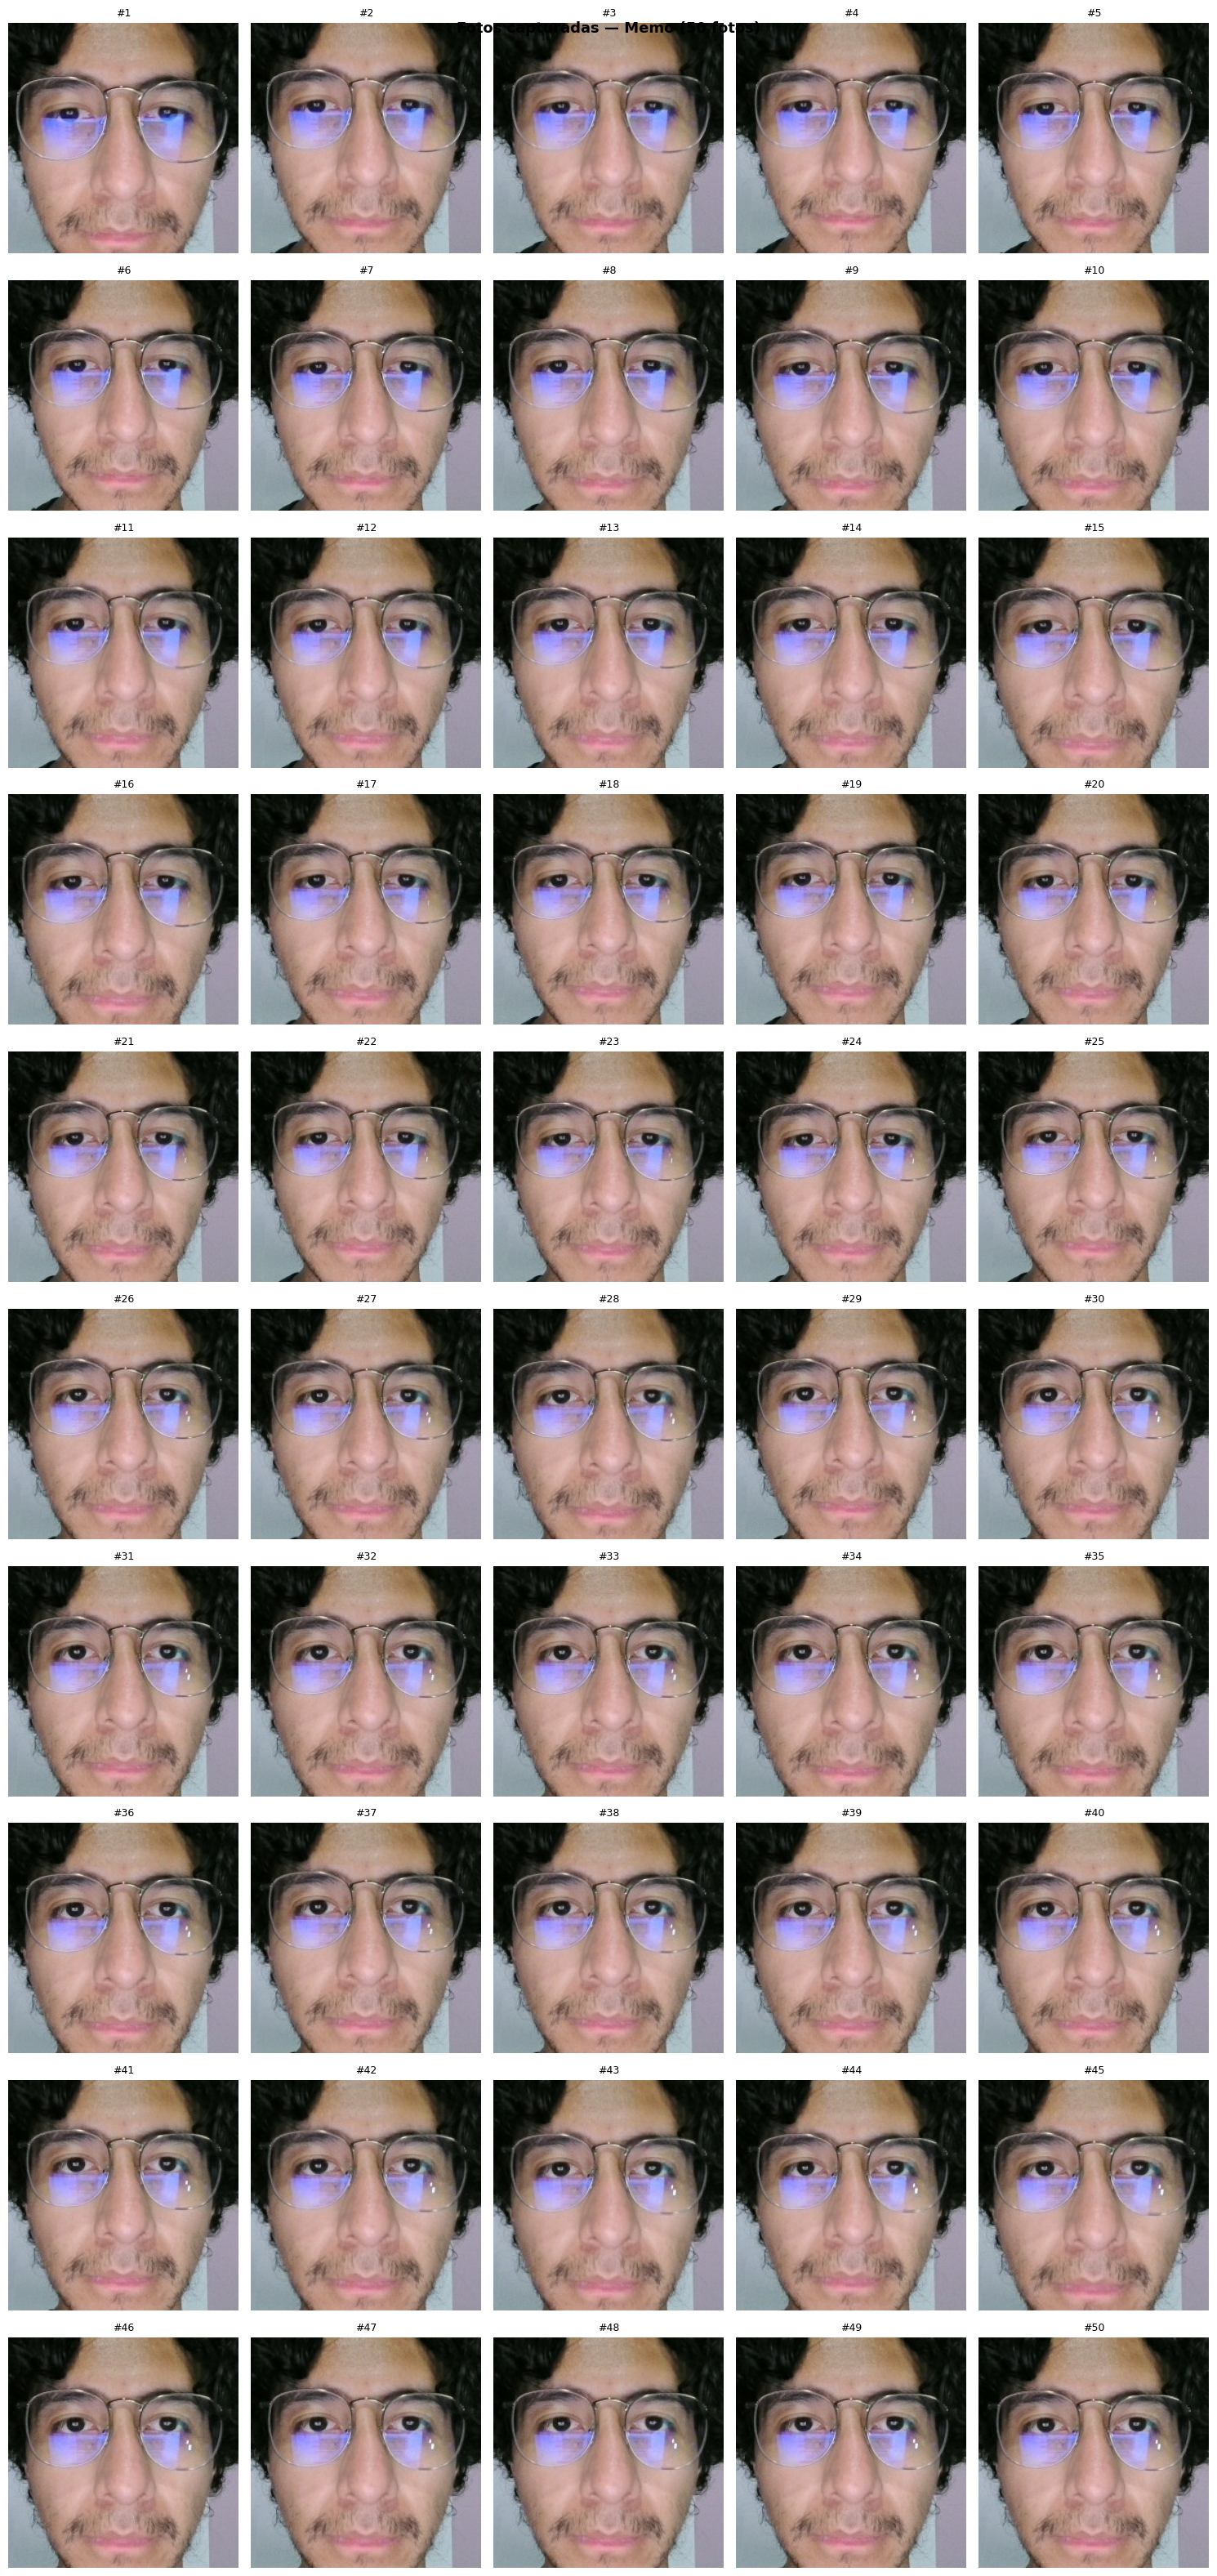

✅ Todo bien — ahora comprime la carpeta y mándala


In [8]:
# Cell 4 — Verificación visual de las fotos capturadas
import matplotlib.pyplot as plt
import cv2
from pathlib import Path

fotos = sorted(Path(f'{DATASET_DIR}/{NOMBRE}').glob('*.jpg'))
print(f'Total de fotos encontradas: {len(fotos)}')

cols = 5
rows = (len(fotos) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3.2))
axes = [ax for row in (axes if rows > 1 else [axes]) for ax in (row if cols > 1 else [row])]

fig.suptitle(f'Fotos capturadas — {NOMBRE.replace("_"," ").title()} ({len(fotos)} fotos)',
             fontsize=13, fontweight='bold')

for i, ruta in enumerate(fotos):
    img = cv2.cvtColor(cv2.imread(str(ruta)), cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(f'#{i+1}', fontsize=9)
    axes[i].axis('off')

for j in range(len(fotos), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(f'preview_{NOMBRE}.png', dpi=100, bbox_inches='tight')
plt.show()

if len(fotos) >= 20:
    print('✅ Todo bien — ahora comprime la carpeta y mándala')
else:
    print(f'⚠️  Solo tienes {len(fotos)}/20 fotos — vuelve a ejecutar la Cell 3')

In [9]:
# Cell 5 — Comprimir carpeta para enviar
import shutil

nombre_zip = f'dataset_{NOMBRE}'
shutil.make_archive(nombre_zip, 'zip', '.', f'{DATASET_DIR}/{NOMBRE}')

import os
tamanio = os.path.getsize(f'{nombre_zip}.zip') / 1024
print(f'✅ Archivo listo: {nombre_zip}.zip  ({tamanio:.0f} KB)')
print(f'   Mándale ese archivo a José Luis')

✅ Archivo listo: dataset_memo.zip  (1038 KB)
   Mándale ese archivo a José Luis
